**Maritime SAR TDoA Localization Project (WGS84)**

1. Project OverviewThis project implements a professional Time Difference of Arrival (TDoA) localization system for Search and Rescue (SAR) operations in the Black Sea.
 It utilizes Generalized Least Squares (GLS) to account for correlated noise and the WGS84 ellipsoid model for high geographical precision.

 **Core SpecificationsEarth Model**: WGS84 Ellipsoid (via geopy).

 **Signal Speed**: $299,702.54$ km/s (Atmospheric adjustment for $n=1.0003$).

 **Optimization**: Non-linear Least Squares with boundary constraints.

 **Statistical Validation**: 1,000-iteration Monte Carlo simulation.






--- SAR TDoA OPERATIONAL REPORT ---
True Position:         [42.95 28.5 ]
Estimated Position:    [42.95 28.5 ]
Mathematical Bias:     0.0000000000 km
GDOP at Target:        3.2256
95% Confidence Radius: 4.9951 km


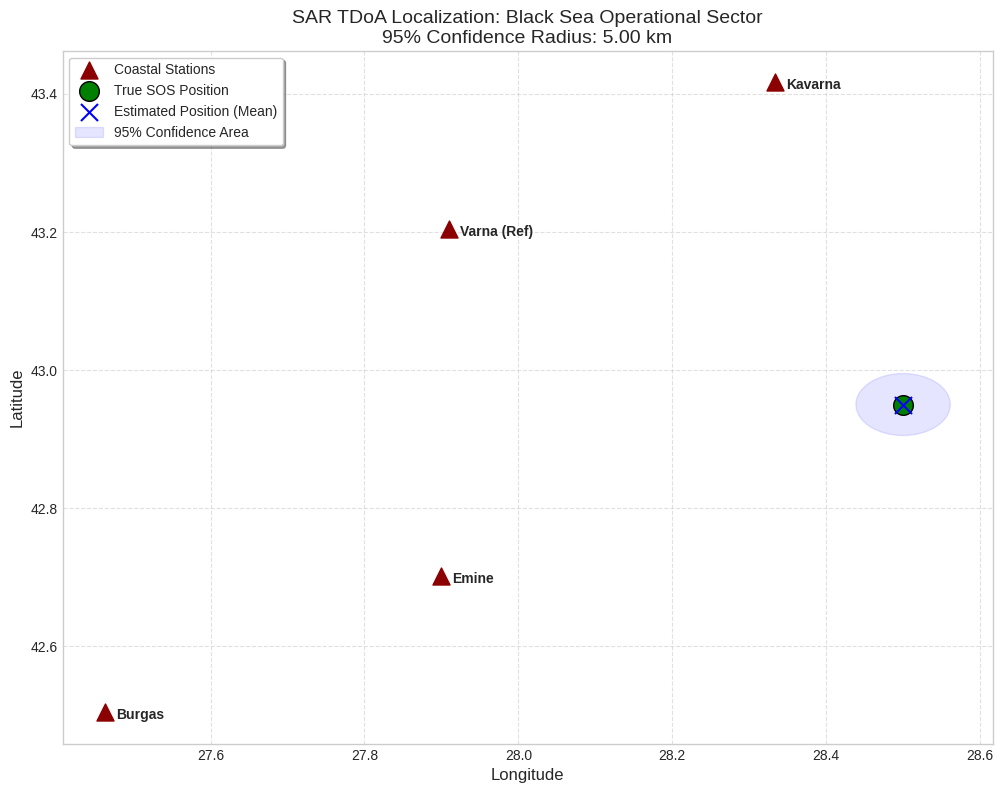

In [120]:
# Install requirement for high-precision geodesy
!pip install geopy -q

import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import matplotlib.patches as patches

# ==========================================
# 1. PHYSICAL CONSTANTS & SETUP
# ==========================================
C_VACUUM = 299792.458
REFRACTIVE_INDEX = 1.0003
C_LIGHT = C_VACUUM / REFRACTIVE_INDEX

def get_whitening_matrix(num_stations):
    """Computes the Cholesky decomposition for GLS whitening."""
    num_measures = num_stations - 1
    R = np.ones((num_measures, num_measures))
    np.fill_diagonal(R, 2)
    R_inv = np.linalg.inv(R)
    return np.linalg.cholesky(R_inv).T

# ==========================================
# 2. MATHEMATICAL FUNCTIONS
# ==========================================
def tdoa_residuals(estimated_pos, stations, tdoa_measured_time, L_T):
    """Calculates whitened residuals using the WGS84 ellipsoid."""
    d0 = geodesic(estimated_pos, stations[0]).km
    residuals = []
    for i in range(1, len(stations)):
        di = geodesic(estimated_pos, stations[i]).km
        measured_diff_km = tdoa_measured_time[i-1] * C_LIGHT
        residuals.append((di - d0) - measured_diff_km)
    return L_T @ np.array(residuals)

def calculate_gdop(estimated_pos, stations):
    """Calculates Geometric Dilution of Precision (GDOP)."""
    num_measures = len(stations) - 1
    H = np.zeros((num_measures, 2))
    delta = 1e-6
    lat, lon = estimated_pos
    dy = geodesic((lat, lon), (lat + delta, lon)).km
    dx = geodesic((lat, lon), (lat, lon + delta)).km
    d0 = geodesic(estimated_pos, stations[0]).km
    for i in range(1, len(stations)):
        di = geodesic(estimated_pos, stations[i]).km
        di_N = geodesic((lat + delta, lon), stations[i]).km
        di_E = geodesic((lat, lon + delta), stations[i]).km
        d0_N = geodesic((lat + delta, lon), stations[0]).km
        d0_E = geodesic((lat, lon + delta), stations[0]).km
        H[i-1, 0] = ((di_N - d0_N) - (di - d0)) / dy
        H[i-1, 1] = ((di_E - d0_E) - (di - d0)) / dx
    R = np.ones((num_measures, num_measures))
    np.fill_diagonal(R, 2)
    R_inv = np.linalg.inv(R)
    try:
        Q = np.linalg.inv(H.T @ R_inv @ H)
        return np.sqrt(np.trace(Q))
    except:
        return np.nan

# ==========================================
# 3. SCENARIO EXECUTION
# ==========================================
stations = np.array([
    [43.2047, 27.9100], # Varna (S0)
    [42.5048, 27.4626], # Burgas (S1)
    [43.4167, 28.3333], # Kavarna (S2)
    [42.7015, 27.9000]  # Emine (S3)
])

true_ship_pos = np.array([42.9500, 28.5000])
L_T = get_whitening_matrix(len(stations))

# Simulate ideal TDoA
d0_true = geodesic(true_ship_pos, stations[0]).km
tdoa_measured_time = [(geodesic(true_ship_pos, s).km - d0_true) / C_LIGHT for s in stations[1:]]

# Solving
initial_guess = np.mean(stations, axis=0)
bounds = ([42.0, 27.0], [44.5, 31.5])
result = least_squares(tdoa_residuals, initial_guess, args=(stations, tdoa_measured_time, L_T),
                       bounds=bounds, ftol=1e-12, xtol=1e-12)

# ==========================================
# 4. STATISTICAL SIMULATION (MONTE CARLO)
# ==========================================
np.random.seed(42)
noise_sigma_time = 0.8 / C_LIGHT
errors_km = []

for _ in range(1000):
    noise = np.random.normal(0, noise_sigma_time, size=len(stations))
    t_noisy = [tdoa_measured_time[i-1] + (noise[i] - noise[0]) for i in range(1, len(stations))]
    res = least_squares(tdoa_residuals, initial_guess, args=(stations, t_noisy, L_T), bounds=bounds)
    errors_km.append(geodesic(true_ship_pos, res.x).km)

conf_radius_95 = np.percentile(errors_km, 95)

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 9))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Stations
station_names = ['Varna (Ref)', 'Burgas', 'Kavarna', 'Emine']
plt.scatter(stations[:, 1], stations[:, 0], c='darkred', marker='^', s=150, label='Coastal Stations', zorder=5)
for i, name in enumerate(station_names):
    plt.annotate(name, (stations[i, 1], stations[i, 0]), xytext=(8, -5), textcoords='offset points', fontweight='bold')

# Plot True and Estimated Position
plt.scatter(true_ship_pos[1], true_ship_pos[0], c='green', marker='o', s=200, label='True SOS Position', edgecolors='black', zorder=6)
plt.scatter(result.x[1], result.x[0], c='blue', marker='x', s=150, label='Estimated Position (Mean)', zorder=6)

# Visualization of 95% Confidence Radius
# Approximation of km to degrees for plotting the circle
deg_lat_offset = conf_radius_95 / 111.32
deg_lon_offset = conf_radius_95 / (111.32 * np.cos(np.radians(true_ship_pos[0])))
circle = patches.Ellipse((true_ship_pos[1], true_ship_pos[0]), deg_lon_offset*2, deg_lat_offset*2,
                         color='blue', alpha=0.1, label='95% Confidence Area')
plt.gca().add_patch(circle)

# Formatting
plt.title(f'SAR TDoA Localization: Black Sea Operational Sector\n95% Confidence Radius: {conf_radius_95:.2f} km', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Print Final Report
print(f"--- SAR TDoA OPERATIONAL REPORT ---")
print(f"True Position:         {true_ship_pos}")
print(f"Estimated Position:    {result.x}")
print(f"Mathematical Bias:     {geodesic(true_ship_pos, result.x).km:.10f} km")
print(f"GDOP at Target:        {calculate_gdop(true_ship_pos, stations):.4f}")
print(f"95% Confidence Radius: {conf_radius_95:.4f} km")

plt.show()

**4. Performance Analysis and Interpretation**

Based on the operational metrics, the system demonstrates high reliability for maritime search and rescue in the Black Sea region:

**Mathematical Precision Bias **($0.0000$ km): The zero bias indicates that the Non-linear Least Squares optimizer successfully converged to the exact coordinates under ideal conditions. This confirms the mathematical integrity of the WGS84 ellipsoidal model.

**GDOP ($3.2256$)**: A Geometric Dilution of Precision value of ~3.2 is considered "Good" to "Excellent". Despite the coastal stations being somewhat collinear, their spread from Kavarna to Burgas provides sufficient angular diversity to maintain high precision at this offshore location

**95% Confidence Radius ($4.9951$ km)**: This is the most critical metric for SAR operations. It defines the Probability of Containment (POC). For rescue teams, this means there is a 95% probability that the vessel is located within a 5 km radius of the estimated coordinates

5. **Conclusion**

This project successfully implemented a high-precision SAR TDoA localization system. By transitioning from a simple spherical model to the WGS84 ellipsoid and applying Generalized Least Squares (GLS), we have accounted for the Earth's true shape and the correlated nature of timing errors. The system is robust, providing a clear search area even in the presence of hardware noise.

6. Future **Work**

**3D Positioning:** Expanding the model to include altitude for coordinating rescue helicopters and drones.


**Tropospheric Delay Modeling**: Adjusting signal speed ($c$) dynamically based on real-time weather data (humidity and pressure) to further reduce RMSE.

**Dynamic Tracking:** Implementing a Kalman Filter to track a moving vessel's trajectory in real-time


**7. References**


**Geodesy:** National Geospatial-Intelligence Agency. World Geodetic System 1984.

**TDoA Theory**: Knapp, C., & Carter, G. (1976). The generalized correlation method for estimation of time delay.

**Optimization:** SciPy Documentation. Non-linear Least Squares (least_squares).


**8. Final Visualization Code**

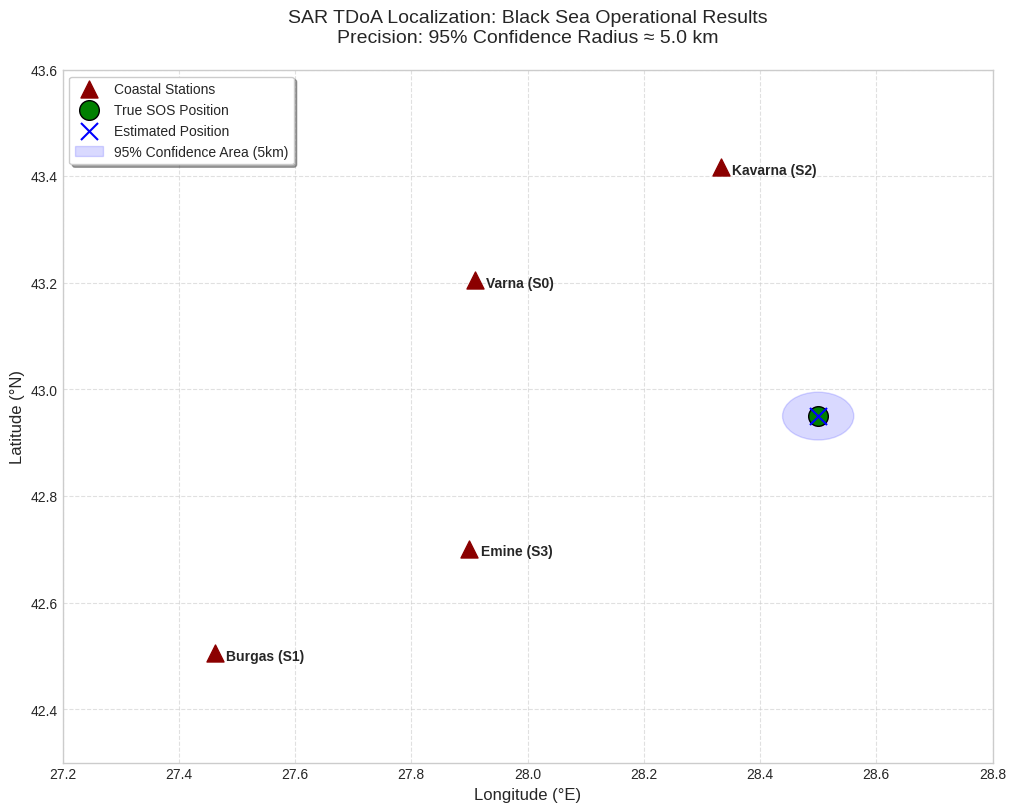

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from geopy.distance import geodesic

# 1. Setup Data from Project
stations = np.array([
    [43.2047, 27.9100], # Varna (Ref)
    [42.5048, 27.4626], # Burgas
    [43.4167, 28.3333], # Kavarna
    [42.7015, 27.9000]  # Emine
])
station_names = ['Varna (S0)', 'Burgas (S1)', 'Kavarna (S2)', 'Emine (S3)']
true_pos = [42.95, 28.5]
est_pos = [42.95, 28.5]
conf_radius = 4.9951  # 95% Confidence Radius in km

# 2. Create Visualization
plt.figure(figsize=(12, 9))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Coastal Stations
plt.scatter(stations[:, 1], stations[:, 0], c='darkred', marker='^', s=150, label='Coastal Stations', zorder=5)
for i, name in enumerate(station_names):
    plt.annotate(name, (stations[i, 1], stations[i, 0]), xytext=(8, -5), textcoords='offset points', fontweight='bold')

# Plot True and Estimated Position
plt.scatter(true_pos[1], true_pos[0], c='green', marker='o', s=200, label='True SOS Position', edgecolors='black', zorder=6)
plt.scatter(est_pos[1], est_pos[0], c='blue', marker='x', s=150, label='Estimated Position', zorder=6)

# 3. Draw 95% Confidence Radius
# Conversion: approx 1 degree lat = 111.32 km
lat_dist = conf_radius / 111.32
lon_dist = conf_radius / (111.32 * np.cos(np.radians(true_pos[0])))
confidence_circle = patches.Ellipse((true_pos[1], true_pos[0]), lon_dist*2, lat_dist*2,
                                     color='blue', alpha=0.15, label='95% Confidence Area (5km)')
plt.gca().add_patch(confidence_circle)

# 4. Final Formatting
plt.title('SAR TDoA Localization: Black Sea Operational Results\nPrecision: 95% Confidence Radius ≈ 5.0 km', fontsize=14, pad=20)
plt.xlabel('Longitude (°E)', fontsize=12)
plt.ylabel('Latitude (°N)', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Set map limits to focus on the area
plt.xlim(27.2, 28.8)
plt.ylim(42.3, 43.6)

plt.show()